In [1]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from src.green_gecko_model import CAModel, make_seed

# Visualizing the burn-in phase of getting to the attractor
### Load the model

In [2]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_PADDING = 16   # Number of pixels used to pad the target image border
TARGET_SIZE = 40
CELL_FIRE_RATE = 1. #0.5

# My own defined things
size = TARGET_SIZE + TARGET_PADDING * 2
x_start, y_start = TARGET_PADDING, TARGET_PADDING # size//2-2, size//2-2
x_end, y_end = TARGET_PADDING+TARGET_SIZE, TARGET_PADDING+TARGET_SIZE # size//2+2, size//2+2

# Whether to scale the attractor or not
scale_attractor = False

In [3]:
model = CAModel(channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE)
model.load_weights("model/plain_salamander/big_fire_rate1/8000.weights.h5")
None

2026-04-05 17:21:38.110216: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-05 17:21:38.110241: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-05 17:21:38.110245: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-05 17:21:38.110270: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-05 17:21:38.110282: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-05 17:21:38.404295: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


### Run the model for a bit

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.028648216..1.0251812].


(1301, 1, 40, 40, 16)
(40, 40, 16)


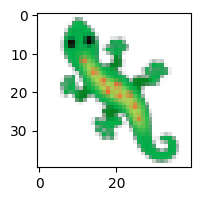

In [4]:
seed = make_seed(TARGET_SIZE+TARGET_PADDING*2, n=1, channel_n=CHANNEL_N)
x = tf.convert_to_tensor(seed)

states = [tf.identity(x).numpy()]

for iter in range(1300):
    x = model(x)
    states.append(tf.identity(x).numpy())

states_np = np.stack(states)[:,:,x_start:x_end,y_start:y_end] #[:,:,10:-10,10:-10]
print(states_np.shape)

x_star = states_np[-1,0]
print(x_star.shape)
plt.figure(figsize=(2,2))
plt.imshow(x_star[:,:,:4])

### Plot the "falling in" phase

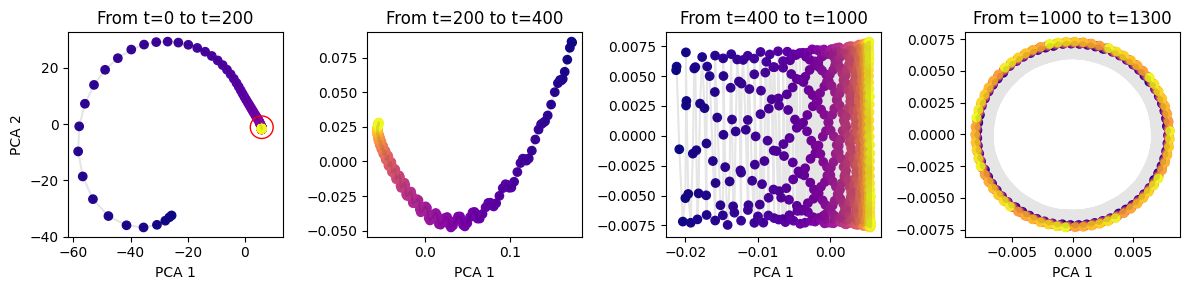

In [5]:
flattened_attractor_states = states_np.reshape(states_np.shape[0], -1)
timesteps = np.arange(flattened_attractor_states.shape[0])

if scale_attractor:
    scaler = StandardScaler()
    scaler = scaler.fit(flattened_attractor_states[2000:]) # originally 2000
    flattened_attractor_states_scaled = scaler.transform(flattened_attractor_states)

timesteps = [0, 200, 400, 1000,1300]

def plot_falling_in(flattened_states, timesteps, high_light_step=60):
    plt.figure(figsize=(12,3))

    for i in range(len(timesteps)-1):
        t1, t2 = timesteps[i], timesteps[i+1]

        pca_states = PCA(n_components=2).fit_transform(flattened_states[t1:t2])

        plt.subplot(1, len(timesteps)-1, i+1)
        plt.title(f"From t={t1} to t={t2}")
        plt.scatter(pca_states[:, 0], pca_states[:, 1], c=np.arange(pca_states.shape[0])/pca_states.shape[0], cmap="plasma")
        plt.plot(pca_states[:, 0], pca_states[:, 1], 'k-', alpha=0.1)
        plt.xlabel("PCA 1")
        if i == 0:
            plt.ylabel("PCA 2")

        if t1 <= high_light_step <= t2:
            circle = plt.Circle((pca_states[high_light_step, 0], pca_states[high_light_step, 1]), 4, facecolor="#C3262600", edgecolor="#FF0000FF")
            plt.gca().add_patch(circle)

    plt.tight_layout()

plot_falling_in(flattened_attractor_states, timesteps)